# Character consistency with SDXL LoRA: executed run

This is the executed record of the full pipeline, run on a Colab **L4 GPU** on 2026-09-21, with outputs retained. See the [repo README](https://github.com/Colin-J-Emmanuel/character-consistency-lora) for the method and [RESULTS.md](https://github.com/Colin-J-Emmanuel/character-consistency-lora/blob/main/RESULTS.md) for the full tables.

One-time patches and failed attempts from the session have been removed; those fixes now live in the repo code and in the setup cells below. Where a kept output shows an error or a first attempt, a note explains it.

To re-run on a **T4**, replace `train_lora.sh` with `train_lora_t4.sh` in step 3.

## Setup

In [4]:
from google.colab import drive; drive.mount('/content/drive')
!nvidia-smi --query-gpu=name,memory.total --format=csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
name, memory.total [MiB]
NVIDIA L4, 23034 MiB


In [5]:
!git clone https://github.com/Colin-J-Emmanuel/character-consistency-lora.git
%cd character-consistency-lora

Cloning into 'character-consistency-lora'...
remote: Enumerating objects: 109, done.
remote: Total 109 (delta 0), reused 0 (delta 0), pack-reused 109 (from 1)
Receiving objects: 100% (109/109), 42.24 MiB | 15.40 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/character-consistency-lora


In [6]:
!pip install -q diffusers transformers accelerate peft safetensors bitsandbytes ftfy datasets
!pip install -q "protobuf>=5.29.1,<6"
!mkdir -p /content/drive/MyDrive/ccl && ln -sfn /content/drive/MyDrive/ccl outputs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [7]:
# Also required on current Colab images. In the original session these were
# applied later, when each problem appeared; consolidated here for a fresh run.
!pip uninstall -y -q torchao                  # PEFT rejects Colab's torchao 0.10
!pip install -q "opencv-python-headless<5"    # OpenCV 5 removed the Haar face detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 43.9 MB/s eta 0:00:00


**Restart the session** (Runtime > Restart session) after the installs, then re-run the Drive mount and `%cd /content/character-consistency-lora` before continuing. The protobuf pin only takes effect in a fresh process.

## 1. Baseline: text only

In this run, generation succeeded but scoring failed on the transformers 5 API change shown in the output below. The fix is in the repo; the second cell rescored the saved images without regenerating them.

In [8]:
!python eval/consistency_experiment.py --out_dir results/baseline

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 631/631 [00:00<00:00, 3.49MB/s]

diffusion_pytorch_model.safetensors: downloading bytes:   0% 0.00/335M [00:00<?, ?B/s]
diffusion_pytorch_model.safetensors: downloading bytes:  65% 217M/335M [00:01<00:00, 280MB/s, 13.5MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file:  58% 194M/335M [00:01<00:00, 142MB/s,  136kB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes:  83% 279M/335M [00:01<00:00, 289MB/s, 25.1MB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes: 100% 316M/316M [00:02<00:00, 138MB/s, 28.8MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file: 100% 335M/335M [00:02<00:00, 146MB/s, 30.9MB/s  ]
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecatio

In [9]:
!python eval/consistency_experiment.py --out_dir results/baseline --eval_only

Loading weights: 100% 590/590 [00:00<00:00, 5760.86it/s]
Loading weights: 100% 223/223 [00:00<00:00, 4121.43it/s]

arm             DINO self  DINO worst  CLIP-I self  CLIP-T scene
----------------------------------------------------------------
prompt_only        0.2391      0.0598       0.7999        0.2325
fixed_seed         0.2914      0.1303       0.8220        0.2091
high_cfg           0.3019      0.1138       0.7947        0.2125

wrote results/baseline/eval.json


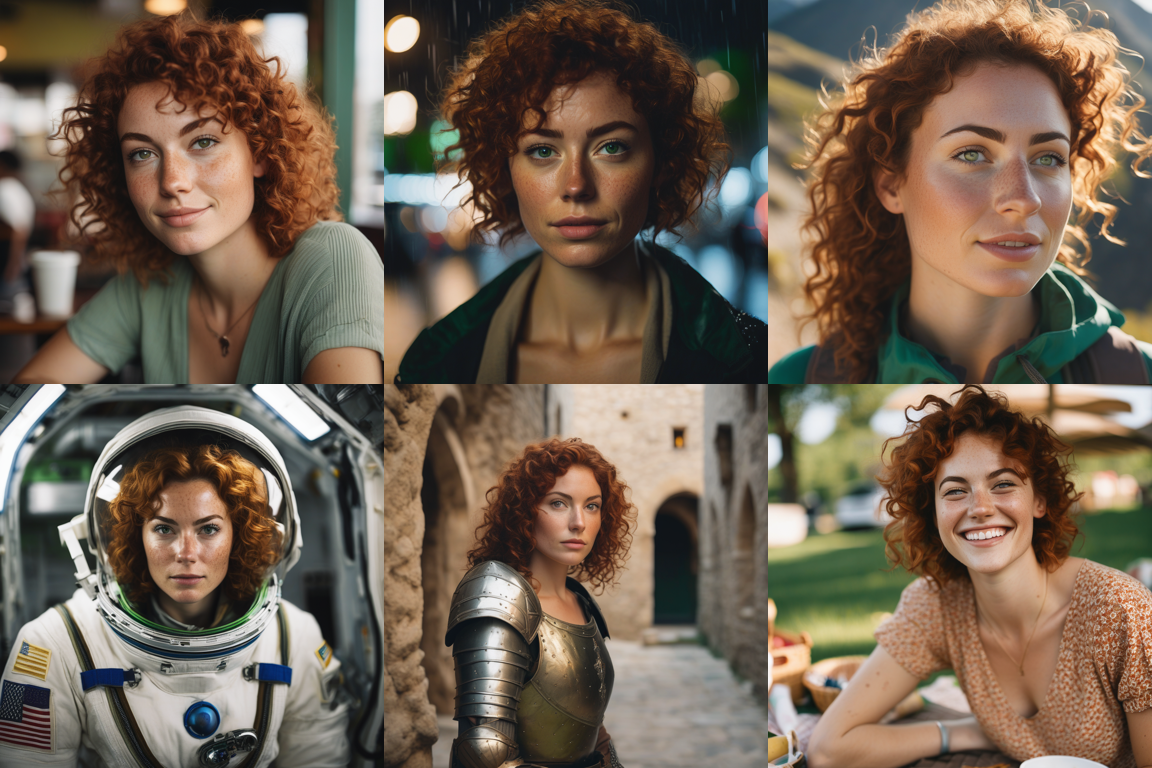

In [10]:
from IPython.display import Image as D
D("results/baseline/grid_prompt_only.png", width=700)

In [11]:
!cp -r results /content/drive/MyDrive/ccl/

## 2. Training set

The first attempt used the default img2img strength of 0.5 and produced near-duplicates: DINO self-consistency 0.971. It was regenerated at 0.65 (0.950), which is the set used for training. Img2img from one frontal reference cannot produce new head poses at any strength that preserves the face.

In [12]:
!python scripts/make_character_set.py --out_dir data/my_character

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights: 100% 196/196 [00:00<00:00, 5789.20it/s]
Loading pipeline components...:  57% 4/7 [00:00<00:00,  8.38it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights: 100% 517/517 [00:00<00:00, 4625.91it/s]
Loading pipeline components...: 100% 7/7 [00:00<00:00,  8.65it/s]
hero saved
variation 1: three-quarter view portrait, soft window light, plain wall background
variation 2: profile view portrait,

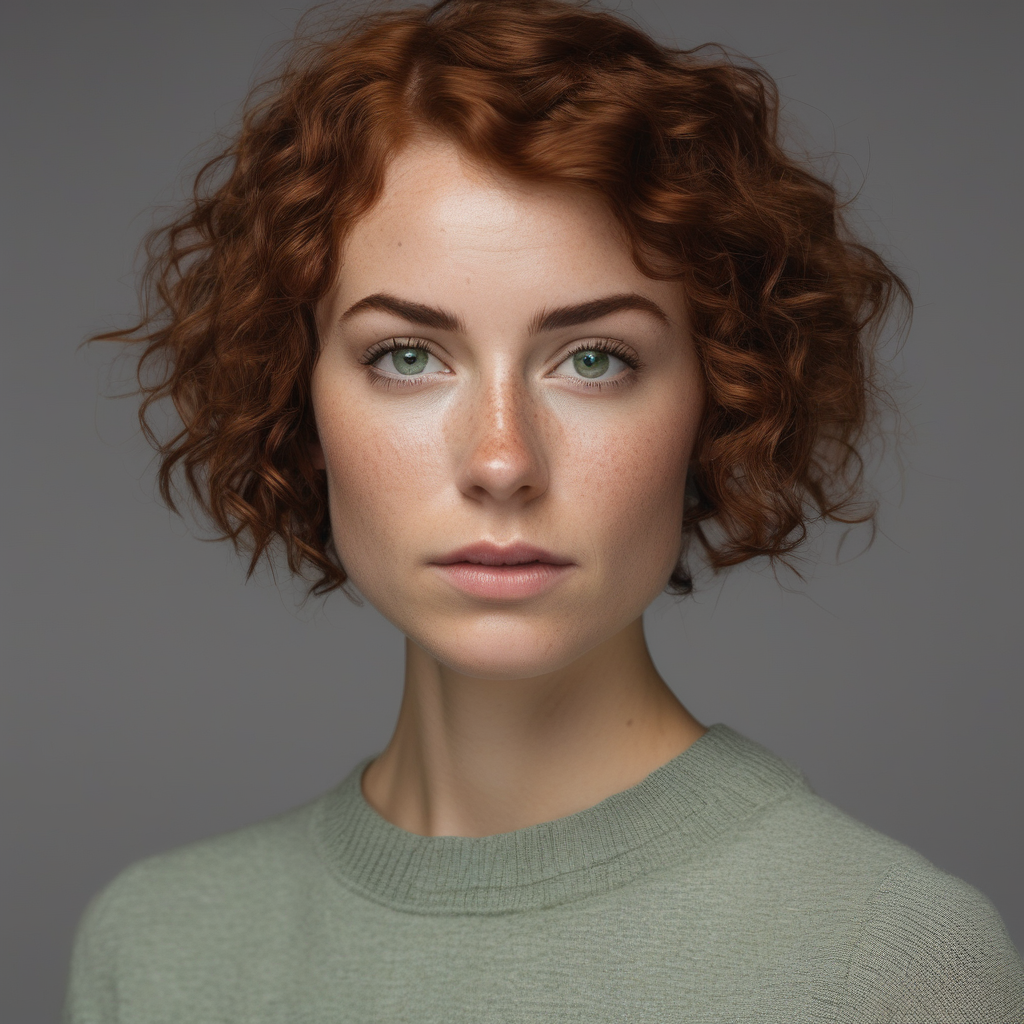

In [13]:
from IPython.display import Image as D
D("data/my_character/00_hero.png", width=450)

In [14]:
!python eval/consistency_experiment.py --eval_dir data/my_character

Loading weights: 100% 590/590 [00:00<00:00, 5577.73it/s]
Loading weights: 100% 223/223 [00:00<00:00, 4832.40it/s]
{
  "n_images": 12,
  "clip_i_self_consistency_mean": 0.9745,
  "clip_i_self_consistency_worst_pair": 0.9483,
  "dino_self_consistency_mean": 0.9711,
  "dino_self_consistency_worst_pair": 0.9418,
  "per_pair_dino": [
    0.9761,
    0.9817,
    0.976,
    0.9745,
    0.9723,
    0.9779,
    0.9717,
    0.9539,
    0.9611,
    0.9731,
    0.9826,
    0.9766,
    0.9731,
    0.9782,
    0.9811,
    0.9759,
    0.98,
    0.9596,
    0.9772,
    0.9716,
    0.9752,
    0.9782,
    0.9736,
    0.9803,
    0.9759,
    0.9738,
    0.947,
    0.9806,
    0.9714,
    0.9744,
    0.9618,
    0.9723,
    0.9769,
    0.9691,
    0.9676,
    0.9666,
    0.971,
    0.9777,
    0.977,
    0.9707,
    0.9687,
    0.951,
    0.9659,
    0.9817,
    0.9748,
    0.9768,
    0.9729,
    0.9545,
    0.9843,
    0.972,
    0.9653,
    0.9792,
    0.9681,
    0.9707,
    0.9778,
    0.9752,
    0

In [15]:
!cp -r data/my_character /content/drive/MyDrive/ccl/

In [16]:
!mv /content/drive/MyDrive/ccl/my_character /content/drive/MyDrive/ccl/my_character_s050
!rm -rf data/my_character
!python scripts/make_character_set.py --out_dir data/my_character --strength 0.65
!python eval/consistency_experiment.py --eval_dir data/my_character

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights: 100% 517/517 [00:00<00:00, 4521.12it/s]
Loading pipeline components...:  43% 3/7 [00:00<00:00,  5.55it/s]
Loading weights: 100% 196/196 [00:00<00:00, 5968.72it/s]
Loading pipeline components...: 100% 7/7 [00:00<00:00,  8.49it/s]
hero saved
variation 1: three-quarter view portrait, soft window light, plain wall background
variation 2: profile view portrait,

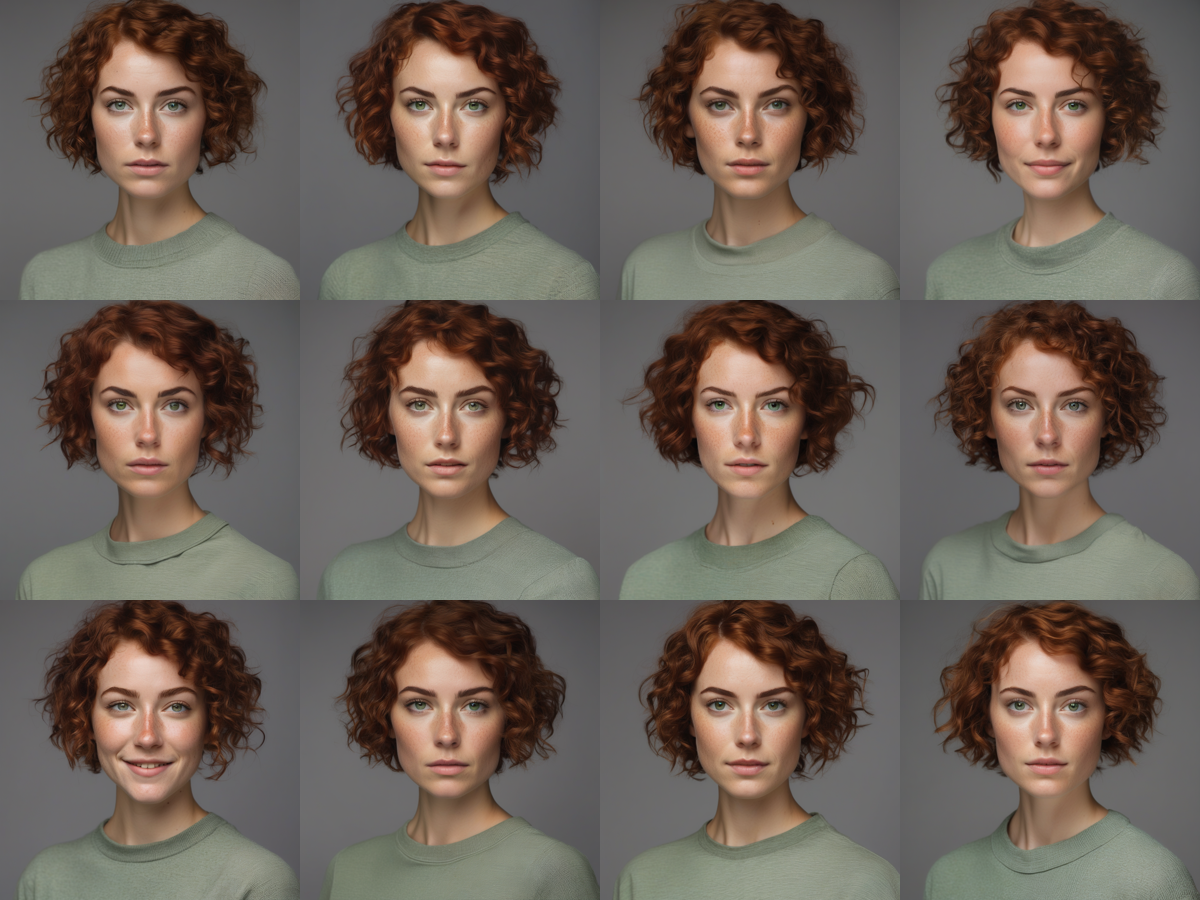

In [17]:
from PIL import Image
import os
d = "data/my_character"
ims = [Image.open(f"{d}/{f}").resize((300, 300)) for f in sorted(os.listdir(d)) if f.endswith(".png")]
sheet = Image.new("RGB", (4 * 300, 3 * 300), "white")
for i, im in enumerate(ims):
    sheet.paste(im, ((i % 4) * 300, (i // 4) * 300))
os.makedirs("results/training_set", exist_ok=True)
sheet.save("results/training_set/grid_s065.png")
sheet

In [18]:
!cp -r data/my_character /content/drive/MyDrive/ccl/

## 3. Train

A 10-step smoke test, then the full 800-step run: about 1.4 seconds per step, 19.5 minutes on the L4. The per-step loss mostly reflects the sampled noise level and is not a quality signal.

In [19]:
!pip uninstall -y -q torchao
!MAX_STEPS=10 bash scripts/train_lora.sh

Fetching train_dreambooth_lora_sdxl.py for diffusers v0.40.0...
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
09/22/2026 00:16:17 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

09/22/2026 00:16:17 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
09/22/2026 00:16:17 - WARNING - huggingface_hub.utils._http - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and

In [20]:
!rm -rf outputs/lora

In [21]:
!INSTANCE_PROMPT="a photo of sks woman, sage green sweater, plain grey backdrop" bash scripts/train_lora.sh

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
09/22/2026 00:22:05 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: bf16

09/22/2026 00:22:06 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
09/22/2026 00:22:06 - WARNING - huggingface_hub.utils._http - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
09/22/2026 00:22:06 - INFO - httpx - HTTP Req

## 4. Evaluate the LoRA: token only

Prompted with `sks woman` alone. On whole frames this looks worse than the baseline, but the shorter prompt widened the compositions, which lowers whole-frame similarity regardless of the faces. Step 5 corrects for that.

In [22]:
!python eval/consistency_experiment.py --out_dir results/lora --lora_dir outputs/lora --character "sks woman"

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading weights:   0% 0/517 [00:00<?, ?it/s]
Loading weights: 100% 517/517 [00:00<00:00, 5153.96it/s]
Loading pipeline components...:  57% 4/7 [00:00<00:00,  9.89it/s]
Loading weights: 100% 196/196 [00:00<00:00, 5789.48it/s]
Loading pipeline components...: 100% 7/7 [00:00<00:00,  8.38it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't o

In [23]:
!python eval/consistency_experiment.py --compare results/baseline/eval.json results/lora/eval.json


eval.json  ->  eval.json

  prompt_only
    dino_self_consistency_mean          0.2391 ->   0.1681  (-0.0710)
    clip_i_self_consistency_mean        0.7999 ->   0.7363  (-0.0636)
    clip_t_scene_fidelity_mean          0.2325 ->   0.2404  (+0.0079)

  fixed_seed
    dino_self_consistency_mean          0.2914 ->   0.2491  (-0.0423)
    clip_i_self_consistency_mean        0.8220 ->   0.7837  (-0.0383)
    clip_t_scene_fidelity_mean          0.2091 ->   0.2348  (+0.0257)

  high_cfg
    dino_self_consistency_mean          0.3019 ->   0.2414  (-0.0605)
    clip_i_self_consistency_mean        0.7947 ->   0.7758  (-0.0189)
    clip_t_scene_fidelity_mean          0.2125 ->   0.2356  (+0.0231)

  Gaps under ~0.05 at this sample size are not conclusive.



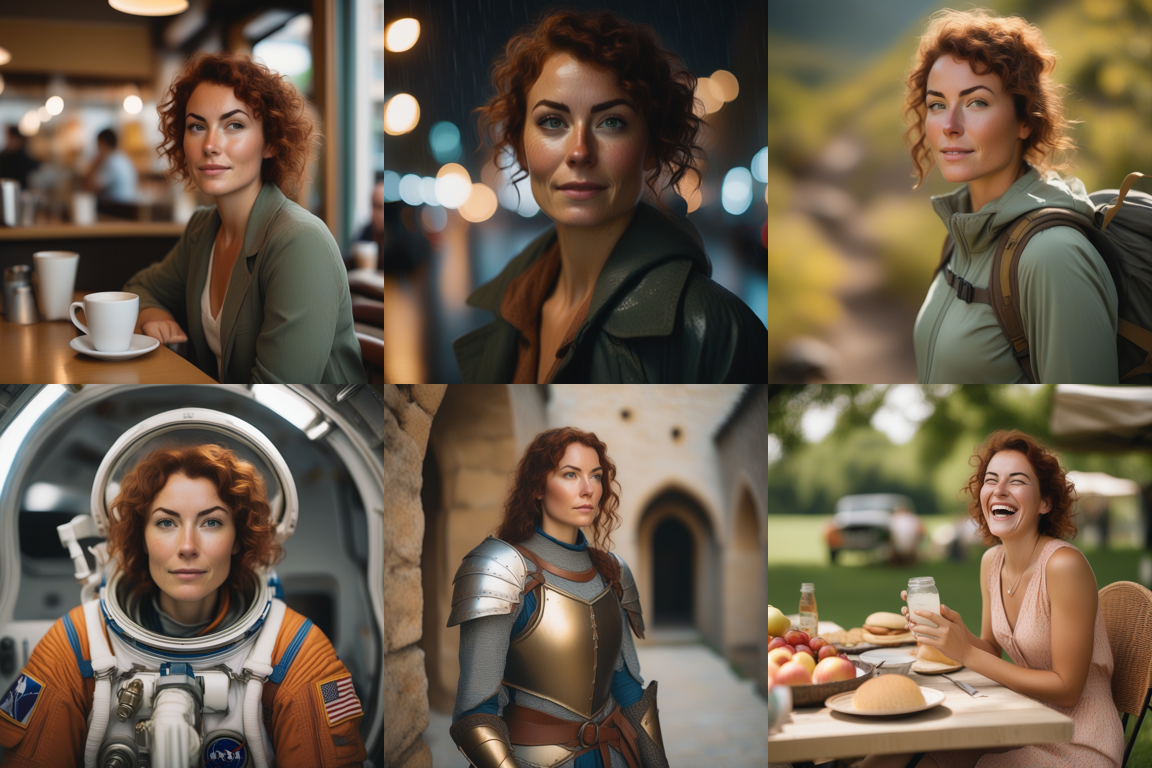

In [24]:
from IPython.display import Image as D
D("results/lora/grid_prompt_only.png", width=700)

## 5. Face-cropped scoring

Scores only the largest detected face in each image, isolating identity from scene and composition. All faces were detected.

In [25]:
!pip install -q "opencv-python-headless<5"
!python -c "import cv2; print(cv2.__version__, hasattr(cv2, 'CascadeClassifier'))"
!python eval/consistency_experiment.py --out_dir results/baseline --eval_only --face_crop
!python eval/consistency_experiment.py --out_dir results/lora --eval_only --face_crop
!python eval/consistency_experiment.py --compare results/baseline/eval_face.json results/lora/eval_face.json

4.14.0 True
Loading weights: 100% 590/590 [00:00<00:00, 5064.88it/s]
Loading weights: 100% 223/223 [00:00<00:00, 5179.85it/s]

arm             DINO self  DINO worst  CLIP-I self  CLIP-T scene
----------------------------------------------------------------
prompt_only        0.5025      0.2159       0.8570           nan   faces 6/6
fixed_seed         0.6626      0.5325       0.8622           nan   faces 6/6
high_cfg           0.6165      0.4756       0.8548           nan   faces 6/6

wrote results/baseline/eval_face.json
Loading weights: 100% 590/590 [00:00<00:00, 6011.21it/s]
Loading weights: 100% 223/223 [00:00<00:00, 5126.86it/s]

arm             DINO self  DINO worst  CLIP-I self  CLIP-T scene
----------------------------------------------------------------
prompt_only        0.5142      0.2599       0.7845           nan   faces 6/6
fixed_seed         0.5807      0.4043       0.8284           nan   faces 6/6
high_cfg           0.5678      0.3651       0.8164           nan   faces 6

## 6. Text + LoRA: the controlled comparison

The full description plus the adapter, compared against the full description alone, so the adapter is the only difference. Results are backed up to Drive at the end.

In [26]:
!python eval/consistency_experiment.py --out_dir results/lora_desc --lora_dir outputs/lora --character "sks woman, a 28-year-old woman with short curly auburn hair, light freckles across the nose, green eyes, and a small scar above the left eyebrow"
!python eval/consistency_experiment.py --out_dir results/lora_desc --eval_only --face_crop
!python eval/consistency_experiment.py --compare results/baseline/eval_face.json results/lora_desc/eval_face.json
!cp -r results /content/drive/MyDrive/ccl/

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...:  29% 2/7 [00:00<00:00,  7.75it/s]
Loading weights: 100% 517/517 [00:00<00:00, 5287.70it/s]
Loading pipeline components...:  71% 5/7 [00:00<00:00,  7.78it/s]
Loading weights: 100% 196/196 [00:00<00:00, 3966.53it/s]
Loading pipeline components...: 100% 7/7 [00:00<00:00,  8.43it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel rela